In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import csv

找不到檔案: ./data/raw/balance_data_Group1.csv
找不到檔案: ./data/raw/balance_data_Group2.csv
找不到檔案: ./data/raw/balance_data_Group3.csv
找不到檔案: ./data/raw/balance_data_Group4.csv
找不到檔案: ./data/raw/balance_data_Group5.csv
====== 各分區資料摘要統計表格 (Non-IID 檢核) ======


""


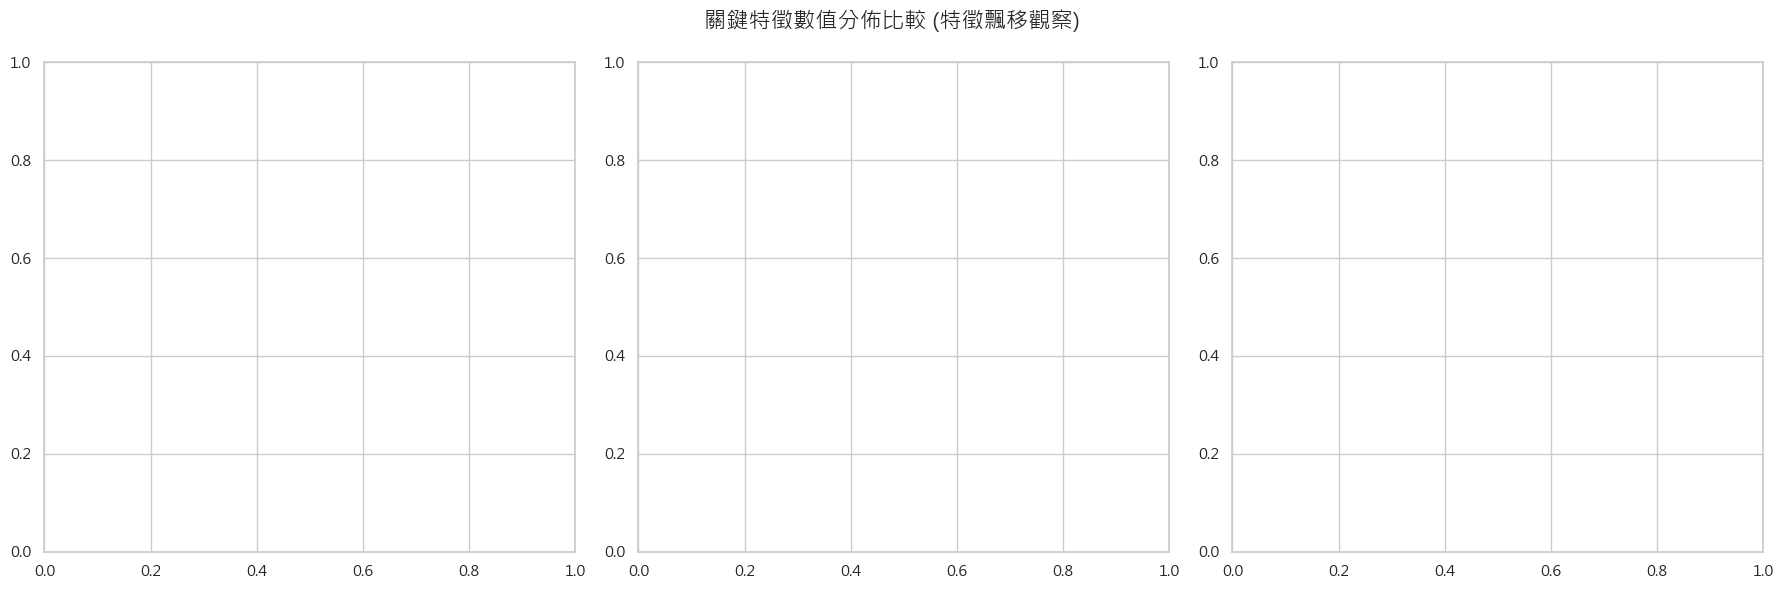

In [ ]:
year_groups = ["Group1", "Group2", "Group3", "Group4", "Group5"]

# ==========================================
# 2. 產出 Non-IID 資料檢核報表與圖表

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang HK', 'SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

key_features = ["LBXGH", "LBXGLU", "LBDLDL"] 
summary_data = []
all_df = pd.DataFrame()

# 讀取資料並計算摘要統計
for group_name in year_groups:
    file_path = f'./src/data_set/balance_data_{group_name}.csv'

    if not os.path.exists(file_path):
        print(f"找不到檔案: {file_path}")
        continue
        
    df = pd.read_csv(file_path)
    
    # 模仿 preprocessing.py 的標籤處理，清理出真實的分佈
    df = df[df['DIQ010'] != 9.0].reset_index(drop=True)
    df['DIQ010'] = df['DIQ010'].replace({3.0: 1.0, 2.0: 0.0})
    
    df['Partition'] = group_name
    all_df = pd.concat([all_df, df], ignore_index=True)
    
    # 計算樣本數與標籤分佈
    total_samples = len(df)
    counts = df['DIQ010'].value_counts()
    pos_count = counts.get(1.0, 0)
    neg_count = counts.get(0.0, 0)
    
    stats = {
        "時間分區": group_name,
        "總樣本數": total_samples,
        "糖尿病 (1)": pos_count,
        "非糖尿病 (0)": neg_count,
    }
    
    # 計算關鍵特徵的平均值與標準差
    for feat in key_features:
        if feat in df.columns:
            stats[f"{feat} 平均值"] = round(df[feat].mean(), 2)
            stats[f"{feat} 標準差"] = round(df[feat].std(), 2)
            
    summary_data.append(stats)

# 輸出表格
print("====== 各分區資料摘要統計表格 (Non-IID 檢核) ======")
summary_df = pd.DataFrame(summary_data)
display(summary_df)


# 圖表 B：關鍵特徵箱型圖
num_features = len(key_features)
fig, axes = plt.subplots(1, num_features, figsize=(6 * num_features, 6))

for i, feat in enumerate(key_features):
    if feat in all_df.columns:
        sns.boxplot(data=all_df, x="Partition", y=feat, ax=axes[i], hue="Partition", palette="pastel", legend=False)
        axes[i].set_title(f"臨床指標: {feat} 世代分佈", fontsize=12)
        axes[i].set_xlabel("NHANES 世代分區")
        axes[i].set_ylabel(feat)

plt.suptitle("關鍵特徵數值分佈比較 (特徵飄移觀察)", fontsize=16)
plt.tight_layout()
plt.show()